# Phần B: Suy luận Thống kê & Mô hình hóa


---

| | |
|---|---|
| **Môn học** | Khoa học Dữ liệu / Suy luận Thống kê |
| **Tài liệu tham khảo** | *Inferential Thinking* — inferentialthinking.com |
| **Dữ liệu** | `student_depression_clean.csv` |
| **Target** | `Depression` (0 = không trầm cảm, 1 = trầm cảm) |

---

### Lộ trình

```
I.   Khởi động & Nhận bàn giao dữ liệu
II.  Kiểm định giả thuyết — A/B Testing (Permutation Test)
III. Ước lượng khoảng tin cậy — Bootstrap CI
IV.  Hồi quy & Phân tích phần dư
V.   Mô hình dự báo 
```

---
# I. Khởi động: Nhận bàn giao dữ liệu từ Thành viên A

Trước khi bắt đầu suy luận, chúng ta cần hiểu rõ **chúng ta đang có gì** và **sẽ làm việc với những biến nào**.

Thành viên A đã thực hiện:
- ✅ Làm sạch dữ liệu (xử lý missing, encode target 0/1)
- ✅ Tính **Pearson r** cho tất cả biến số — đây là kim chỉ nam để chọn biến

### Kết quả từ Phần A (chúng ta *nhận lại*, không tính lại)

| Biến | Pearson r | Nhận xét |
|---|---|---|
| Academic Pressure | **+0.475** | 🔴 Mạnh nhất — **ưu tiên số 1** |
| Financial Stress | **+0.364** | 🟠 Đáng kể — **ưu tiên số 2** |
| Age | −0.227 | 🟡 Yếu — giữ lại để tham khảo |
| Work/Study Hours | +0.209 | 🟡 Yếu — giữ lại cho k-NN |
| Study Satisfaction | −0.168 | 🟡 Yếu — giữ lại để kiểm định |
| CGPA | +0.022 | ⚪ Gần như 0 — **loại khỏi mô hình** |

> **Tại sao quan trọng?** — Chọn biến dựa trên bằng chứng (r từ A) giúp mô hình tập trung vào tín hiệu thực sự, tránh đưa nhiễu vào (CGPA có r ≈ 0 → thêm vào chỉ làm loãng).

In [81]:
# ── I.1 — Import thư viện ────────────────────────────────────────────────────
from datascience import *
import numpy as npZ
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

np.random.seed(42)

In [82]:
TARGET       = 'Depression'
ACADEMIC     = 'Academic Pressure'
FINANCIAL    = 'Financial Stress'
WORKHOURS    = 'Work/Study Hours'
SATISFACTION = 'Study Satisfaction'
AGE          = 'Age'
# Palette nhất quán: đỏ = trầm cảm | xanh = không trầm cảm
C_DEP  = '#E24B4A'
C_NDEP = '#378ADD'
C_NULL = '#B4B2A9'
C_OBS  = '#D85A30'
C_CI   = '#0F6E56'
NAVY   = '#042C53'

FIG_DIR = '../output/figures/'

print("OK")

OK


In [83]:
# ── I.3 — Load dữ liệu & kiểm tra điều kiện bàn giao ────────────────────────
df  = pd.read_csv('student_depression_clean.csv')
tbl = Table.from_df(df)

# Kiểm tra bắt buộc — nếu assert lỗi nghĩa là file A chưa đúng chuẩn
assert df.shape[0] == 27837,              f" Sai số dòng: {df.shape[0]}"
assert df[TARGET].isnull().sum() == 0,   "Target có missing!"
assert set(df[TARGET].unique()) == {0,1},"Target chưa encode 0/1!"

print(f"Shape      : {df.shape}")
print(f"Missing    : {df.isnull().sum().sum()}")
print(f"\nPhân phối target:")
print(df[TARGET].value_counts().to_string())
print("\nOK")
display(df.head())

Shape      : (27837, 12)
Missing    : 0

Phân phối target:
Depression
1    16290
0    11547

OK


,Gender,Age,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,33.0,5.0,8.97,2.0,5-6 hours,Healthy,Yes,3.0,1,No,1
1,Female,24.0,2.0,5.90,5.0,5-6 hours,Moderate,No,3.0,2,Yes,0
2,Male,31.0,3.0,7.03,5.0,Less than 5 hours,Healthy,No,9.0,1,Yes,0
3,Female,28.0,3.0,5.59,2.0,7-8 hours,Moderate,Yes,4.0,5,Yes,1
4,Female,25.0,4.0,8.13,3.0,5-6 hours,Moderate,Yes,1.0,1,No,0


### 💬 Nhận xét sau khi load

Nhìn vào phân phối target:  
- Nếu hai nhóm **tương đối cân bằng** → tốt cho mô hình phân loại  
- Nếu một nhóm chiếm > 80% → dữ liệu mất cân bằng, cần lưu ý khi đánh giá accuracy sau này

Tiếp theo, ta bắt đầu từ câu hỏi cốt lõi:  
> *"Áp lực học tập trung bình của nhóm trầm cảm có thực sự cao hơn nhóm kia — hay chỉ là may mắn trong mẫu?"*

---
# II. Kiểm định Giả thuyết — A/B Testing với Permutation Test

## II.A — Nền tảng lý thuyết

## II. Kiểm định Giả thuyết (A/B Testing) bằng Permutation Test

### II.A — Nền tảng lý thuyết chung

Bảng tương quan ở đã chỉ ra một số biến có xu hướng đi kèm với bệnh Trầm cảm. Tuy nhiên, tương quan trên mẫu chưa chắc đã là quy luật của quần thể. Sự chênh lệch mà ta nhìn thấy có thể chỉ là do ngẫu nhiên.

Để kiểm chứng, ta sử dụng **Kiểm định hoán vị**. Cấu trúc bài toán kiểm định như sau:

* **Giả thuyết Không ($H_0$):** Không có sự khác biệt về biến $X$ giữa hai nhóm Trầm cảm và Không trầm cảm. Phân phối của biến $X$ ở hai nhóm là như nhau. Bất kỳ sự chênh lệch nào quan sát được đều do ngẫu nhiên.
* **Giả thuyết Đối ($H_1$):** Nhóm Trầm cảm có mức độ $X$ thực sự khác biệt so với nhóm Không trầm cảm.
* **Test Statistic (Trị số thống kê):** Sự chênh lệch tuyệt đối giữa trung bình của 2 nhóm: $|Mean(Group_1) - Mean(Group_0)|$.
* **Phương pháp:** Ta sẽ xáo trộn ngẫu nhiên nhãn Trầm cảm 5000 lần. Sau đó, tính xem có bao nhiêu phần trăm trường hợp ngẫu nhiên sinh ra được độ chênh lệch lớn hơn hoặc bằng độ chênh lệch thực tế (p-value).


Tóm tắt các tham số của bài toán kiểm định:

| Khái niệm | Ý nghĩa trong bài toán |
| :--- | :--- |
| **$H_0$ (Giả thuyết Không)** | Hai nhóm có phân phối như nhau — chênh lệch chỉ do ngẫu nhiên. |
| **$H_1$ (Giả thuyết Đối)** | Nhóm trầm cảm có giá trị trung bình thực sự **cao hơn** (hoặc khác biệt). |
| **Test statistic** | `\|mean₁ − mean₀\|` — chênh lệch giữa 2 nhóm. |
| **$\alpha$ (Mức ý nghĩa)** | 0.05 |
| **Luật quyết định** | Nếu **p-value < 0.05** Bác bỏ $H_0$ . |

---

### II.B — Định nghĩa hàm `permutation_test` tổng quát


In [84]:
from IPython.display import display
def two_group_diff(tbl, group_col, val_col):
    g1 = tbl.where(group_col, are.equal_to(1)).column(val_col)
    g0 = tbl.where(group_col, are.equal_to(0)).column(val_col)
    return abs(np.mean(g1) - np.mean(g0)), np.mean(g1), np.mean(g0)


def permutation_test(tbl, group_col, val_col, n_rep=5000):
    obs_diff, mean1, mean0 = two_group_diff(tbl, group_col, val_col)
    combined = tbl.column(val_col)
    n1 = tbl.where(group_col, are.equal_to(1)).num_rows

    sim_diffs = make_array()
    for _ in np.arange(n_rep):
        shuffled = np.random.permutation(combined)
        sim_diff = abs(np.mean(shuffled[:n1]) - np.mean(shuffled[n1:]))
        sim_diffs = np.append(sim_diffs, sim_diff)

    p_val = np.mean(sim_diffs >= obs_diff)
    return obs_diff, sim_diffs, p_val, mean1, mean0


from IPython.display import display

def print_permtest_conclusion(var_name, obs_diff, p_val, mean1, mean0):
   
    from IPython.display import Markdown
    
   
    if p_val < 0.05:
        conclusion_text = f"<span style='color:green'>**BÁC BỎ H₀ (p = {p_val:.4f} < 0.05)**</span><br>" \
                          f"Chỉ có **{p_val*100:.1f}%** xác suất chênh lệch này xảy ra do ngẫu nhiên.<br>" \
                          f"**Có đủ bằng chứng thống kê:** '{var_name}' liên quan có ý nghĩa đến trầm cảm."
    else:
        conclusion_text = f"<span style='color:red'>**KHÔNG BÁC BỎ H₀ (p = {p_val:.4f} &ge; 0.05)**</span><br>" \
                          f"Sự khác biệt chưa đủ lớn để loại trừ yếu tố ngẫu nhiên.<br>" \
                          f"**Chưa đủ bằng chứng thống kê** để kết luận."

    
    md_output = f"""
---
### Kết quả kiểm định: **{var_name}**

| Chỉ số | Giá trị |
| :--- | :--- |
| **Trung bình (Trầm cảm)** | {mean1:.4f} |
| **Trung bình (Không trầm cảm)** | {mean0:.4f} |
| **Chênh lệch quan sát (Diff)** | **{obs_diff:.4f}** |
| **p-value** | **{p_val:.4f}** |

{conclusion_text}
---
"""
 
    display(Markdown(md_output))
print("OK")

OK


## II.C — Áp dụng: Biến `Academic Pressure` (biến mạnh nhất, r = +0.475)

Đây là biến có tương quan cao nhất từ bảng hệ số tương quan 
Ta kỳ vọng p-value sẽ **rất nhỏ**

In [85]:
obs_diff_ac, sim_diffs_ac, p_ac, mean1_ac, mean0_ac = permutation_test(
    tbl, TARGET, ACADEMIC, n_rep=5000
)
print_permtest_conclusion(ACADEMIC, obs_diff_ac, p_ac, mean1_ac, mean0_ac)


---
### Kết quả kiểm định: **Academic Pressure**

| Chỉ số | Giá trị |
| :--- | :--- |
| **Trung bình (Trầm cảm)** | 3.6931 |
| **Trung bình (Không trầm cảm)** | 2.3615 |
| **Chênh lệch quan sát (Diff)** | **1.3316** |
| **p-value** | **0.0000** |

<span style='color:green'>**BÁC BỎ H₀ (p = 0.0000 < 0.05)**</span><br>Chỉ có **0.0%** xác suất chênh lệch này xảy ra do ngẫu nhiên.<br>**Có đủ bằng chứng thống kê:** 'Academic Pressure' liên quan có ý nghĩa đến trầm cảm.
---


## II.D — Áp dụng: Biến `Financial Stress` (r = +0.364)

Tương quan thấp hơn Academic Pressure — ta kiểm tra xem kết quả có vẫn có ý nghĩa?

In [86]:
obs_diff_fs, sim_diffs_fs, p_fs, mean1_fs, mean0_fs = permutation_test(
    tbl, TARGET, FINANCIAL, n_rep=5000
)
print_permtest_conclusion(FINANCIAL, obs_diff_fs, p_fs, mean1_fs, mean0_fs)


---
### Kết quả kiểm định: **Financial Stress**

| Chỉ số | Giá trị |
| :--- | :--- |
| **Trung bình (Trầm cảm)** | 3.5798 |
| **Trung bình (Không trầm cảm)** | 2.5191 |
| **Chênh lệch quan sát (Diff)** | **1.0607** |
| **p-value** | **0.0000** |

<span style='color:green'>**BÁC BỎ H₀ (p = 0.0000 < 0.05)**</span><br>Chỉ có **0.0%** xác suất chênh lệch này xảy ra do ngẫu nhiên.<br>**Có đủ bằng chứng thống kê:** 'Financial Stress' liên quan có ý nghĩa đến trầm cảm.
---


## II.E — Mở rộng: Kiểm định thêm `Study Satisfaction`

`Study Satisfaction` có r = −0.168 (âm — hài lòng cao hơn thì ít trầm cảm hơn).  
Tương quan yếu hơn — liệu kết quả kiểm định có vẫn có ý nghĩa thống kê?

In [87]:
# ── II.E — Permutation test cho Study Satisfaction ───────────────────────────
obs_diff_ss, sim_diffs_ss, p_ss, mean1_ss, mean0_ss = permutation_test(
    tbl, TARGET, SATISFACTION, n_rep=5000
)
print_permtest_conclusion(SATISFACTION, obs_diff_ss, p_ss, mean1_ss, mean0_ss)


---
### Kết quả kiểm định: **Study Satisfaction**

| Chỉ số | Giá trị |
| :--- | :--- |
| **Trung bình (Trầm cảm)** | 2.7506 |
| **Trung bình (Không trầm cảm)** | 3.2153 |
| **Chênh lệch quan sát (Diff)** | **0.4646** |
| **p-value** | **0.0000** |

<span style='color:green'>**BÁC BỎ H₀ (p = 0.0000 < 0.05)**</span><br>Chỉ có **0.0%** xác suất chênh lệch này xảy ra do ngẫu nhiên.<br>**Có đủ bằng chứng thống kê:** 'Study Satisfaction' liên quan có ý nghĩa đến trầm cảm.
---


## II.F — Tổng hợp kết quả Permutation Test

In [88]:
# ── II.F — Bảng tổng hợp toàn bộ kết quả kiểm định ─────────────────────────
results_perm = {
    ACADEMIC    : (obs_diff_ac, p_ac, mean1_ac, mean0_ac),
    FINANCIAL   : (obs_diff_fs, p_fs, mean1_fs, mean0_fs),
    SATISFACTION: (obs_diff_ss, p_ss, mean1_ss, mean0_ss),
}

from IPython.display import display, Markdown

# Khởi tạo tiêu đề bảng Markdown
md_table = "### Bảng Tổng Hợp Kết Quả Kiểm Định A/B Testing\n\n"
md_table += "| Biến | Mean Trầm cảm | Mean Không TC | Chênh lệch (Diff) | p-value | Kết luận |\n"
md_table += "| :--- | :--- | :--- | :--- | :--- | :--- |\n"

# Duyệt qua từng kết quả và thêm vào các hàng của bảng
for var, (diff, pv, m1, m0) in results_perm.items():
    # Tô màu kết luận
    if pv < 0.05:
        sig = "<span style='color:green'>**✅ Bác bỏ H₀**</span>"
    else:
        sig = "<span style='color:red'>**❌ Không bác bỏ**</span>"
        
    # Nối dữ liệu vào bảng
    md_table += f"| **{var}** | {m1:.3f} | {m0:.3f} | {diff:.4f} | **{pv:.4f}** | {sig} |\n"

# In bảng ra màn hình
display(Markdown(md_table))

### Bảng Tổng Hợp Kết Quả Kiểm Định A/B Testing

| Biến | Mean Trầm cảm | Mean Không TC | Chênh lệch (Diff) | p-value | Kết luận |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Academic Pressure** | 3.693 | 2.361 | 1.3316 | **0.0000** | <span style='color:green'>**✅ Bác bỏ H₀**</span> |
| **Financial Stress** | 3.580 | 2.519 | 1.0607 | **0.0000** | <span style='color:green'>**✅ Bác bỏ H₀**</span> |
| **Study Satisfaction** | 2.751 | 3.215 | 0.4646 | **0.0000** | <span style='color:green'>**✅ Bác bỏ H₀**</span> |


### Nhận xét tổng hợp — Mục II

1. **Academic Pressure** cho kết quả mạnh nhất — phù hợp với r cao nhất. 
2. **Financial Stress** và **Study Satisfaction** đều có ý nghĩa thống kê dù r nhỏ hơn — vì dataset lớn (27 837 dòng) giúp test có **statistical power** cao.  
3. Ý nghĩa thống kê ≠ tầm quan trọng thực tế. Biến `Study Satisfaction` dù p < 0.05 nhưng `diff` nhỏ → **effect size thấp** → vai trò thực tiễn hạn chế.

**Sang mục III**, ta đặt câu hỏi: 
> *"Mức áp lực học tập trung bình của sinh viên trầm cảm nằm trong khoảng nào — và ta chắc chắn đến đâu?"*

---
# III. Ước lượng Khoảng Tin Cậy — Bootstrap Confidence Interval

## III.A — Nền tảng lý thuyết

Mục II đã xác nhận *có sự khác biệt*.  
Mục III trả lời: *sự khác biệt đó lớn đến đâu?* — cụ thể hơn, **mean thực của tổng thể** nằm trong khoảng nào?

**Bootstrap**  mô phỏng việc lấy mẫu lặp lại từ tổng thể bằng cách **bốc thăm có hoàn lại** từ chính mẫu ta có:

```
Lặp 5 000 lần:
    Bốc ngẫu nhiên (có hoàn lại) n phần tử từ mẫu gốc
    Tính mean của lần bốc này
    → Lưu vào mảng boot_means

Khoảng tin cậy 95% = [percentile 2.5%, percentile 97.5%] của boot_means
```



## III.B — Định nghĩa hàm `bootstrap_ci`

In [89]:
def bootstrap_ci(data_arr, n_rep=5000, conf=95):

    boot_means = make_array()
    n = len(data_arr)
    for _ in np.arange(n_rep):
        resample = np.random.choice(data_arr, size=n, replace=True)
        boot_means = np.append(boot_means, np.mean(resample))
    alpha = (100 - conf) / 2
    lower = percentile(alpha, boot_means)
    upper = percentile(100 - alpha, boot_means)
    return lower, upper, boot_means


def plot_bootstrap(boot_means, lower, upper, sample_mean, var_name, n):
    """Vẽ bootstrap distribution với CI và sample mean."""
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(boot_means, bins=50, color='#B5D4F4', edgecolor='white',
            label='Bootstrap means (5 000 lần)')
    ax.axvline(lower, color=C_CI, lw=2, ls='--',
               label=f'CI 95% dưới: {lower:.3f}')
    ax.axvline(upper, color=C_CI, lw=2, ls='--',
               label=f'CI 95% trên: {upper:.3f}')
    ax.axvline(sample_mean, color=NAVY, lw=2.5,
               label=f'Sample mean: {sample_mean:.3f}')
    # Tô vùng CI
    ax.axvspan(lower, upper, alpha=0.12, color=C_CI)
    ax.set_title(f'Bootstrap CI 95% — {var_name}\n(Nhóm sinh viên trầm cảm, n = {n:,})',
                 fontsize=12, fontweight='bold', color=NAVY)
    ax.set_xlabel('Mean', fontsize=10)
    ax.set_ylabel('Tần số', fontsize=10)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

from IPython.display import display, Markdown

def print_bootstrap_conclusion(var_name, sample_mean, lower, upper):
    md_output = f"""
---
### Ước lượng Khoảng tin cậy (CI 95%) — **{var_name}**
*(Dành riêng cho nhóm sinh viên Trầm cảm)*

| Chỉ số | Giá trị |
| :--- | :--- |
| **Trung bình mẫu (Sample Mean)** | {sample_mean:.3f} |
| **Khoảng tin cậy 95% (CI)** | **[{lower:.3f}, {upper:.3f}]** |

**KẾT LUẬN:**
&rarr; **Ta ước lượng với 95% độ tin cậy:** Mức `{var_name}` trung bình của sinh viên trầm cảm trong quần thể nằm trong khoảng **[{lower:.3f}, {upper:.3f}]**.
---
"""
    display(Markdown(md_output))

print("OK")

OK


## III.C — Áp dụng: Ước lượng CI cho nhóm sinh viên trầm cảm

Ta tập trung vào **nhóm Depression = 1** và ước lượng mean thực của tổng thể  
cho hai biến quan trọng nhất: `Academic Pressure` và `Financial Stress`.

In [90]:
depressed = tbl.where(TARGET, are.equal_to(1))
print(f"Số sinh viên trầm cảm trong mẫu: {depressed.num_rows:,}")
print(f"(chiếm {depressed.num_rows/tbl.num_rows:.1%} tổng mẫu)\n")
ci_results = {}

Số sinh viên trầm cảm trong mẫu: 16,290
(chiếm 58.5% tổng mẫu)



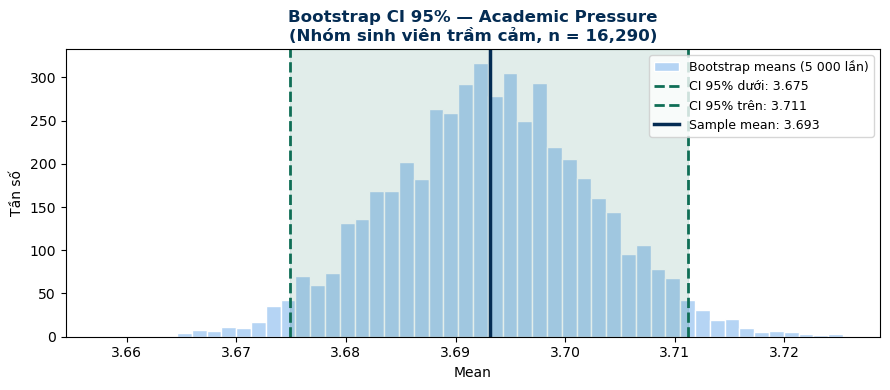


---
### Ước lượng Khoảng tin cậy (CI 95%) — **Academic Pressure**
*(Dành riêng cho nhóm sinh viên Trầm cảm)*

| Chỉ số | Giá trị |
| :--- | :--- |
| **Trung bình mẫu (Sample Mean)** | 3.693 |
| **Khoảng tin cậy 95% (CI)** | **[3.675, 3.711]** |

**KẾT LUẬN:**
&rarr; **Ta ước lượng với 95% độ tin cậy:** Mức `Academic Pressure` trung bình của sinh viên trầm cảm trong quần thể nằm trong khoảng **[3.675, 3.711]**.
---


In [91]:
# Academic Pressure
data_ac = depressed.column(ACADEMIC)
lower_ac, upper_ac, boot_ac = bootstrap_ci(data_ac, n_rep=5000)
ci_results[ACADEMIC] = (lower_ac, upper_ac, np.mean(data_ac))

plot_bootstrap(boot_ac, lower_ac, upper_ac, np.mean(data_ac), ACADEMIC, len(data_ac))

print_bootstrap_conclusion('Academic Pressure', np.mean(data_ac), lower_ac, upper_ac)

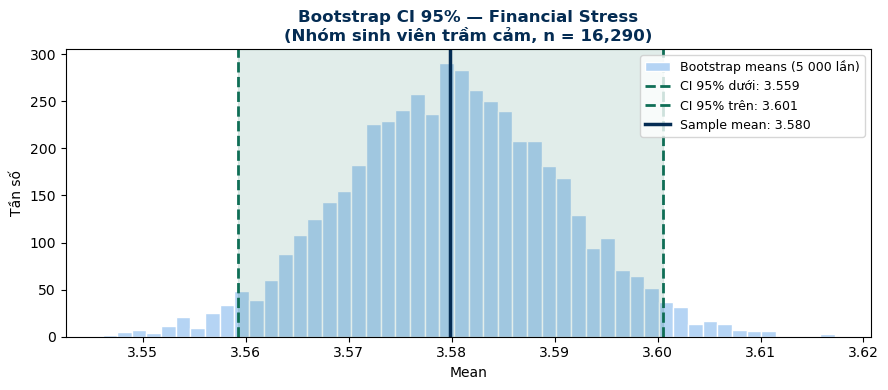


---
### Ước lượng Khoảng tin cậy (CI 95%) — **Financial Stress**
*(Dành riêng cho nhóm sinh viên Trầm cảm)*

| Chỉ số | Giá trị |
| :--- | :--- |
| **Trung bình mẫu (Sample Mean)** | 3.693 |
| **Khoảng tin cậy 95% (CI)** | **[3.675, 3.711]** |

**KẾT LUẬN:**
&rarr; **Ta ước lượng với 95% độ tin cậy:** Mức `Financial Stress` trung bình của sinh viên trầm cảm trong quần thể nằm trong khoảng **[3.675, 3.711]**.
---


In [92]:
#Financial Stress
data_fs = depressed.column(FINANCIAL)
lower_fs, upper_fs, boot_fs = bootstrap_ci(data_fs, n_rep=5000)
ci_results[FINANCIAL] = (lower_fs, upper_fs, np.mean(data_fs))

plot_bootstrap(boot_fs, lower_fs, upper_fs, np.mean(data_fs), FINANCIAL, len(data_fs))

print_bootstrap_conclusion('Financial Stress', np.mean(data_ac), lower_ac, upper_ac)

### Nhận xét — Mục III

- **Khoảng CI hẹp** là dấu hiệu tốt — sample size lớn (n > 10 000) cho ước lượng chính xác.  
- Đây là nền tảng để giải thích "mức rủi ro" trong báo cáo cuối: thay vì nói "áp lực cao hơn", ta nói được cụ thể hơn bao nhiêu điểm.

**Sang mục IV**, ta xây dựng phương trình — biến từ mô tả sang **dự báo**.

# IV. Hồi quy tuyến tính

## IV.A — Nền tảng lý thuyết

Permutation Test và Bootstrap CI trả lời *"có khác biệt không"* và *"khác biệt bao nhiêu"*.  
**Hồi quy** :*"khác biệt đó thay đổi theo chiều nào và với tốc độ ra sao?"*

**Hồi quy tuyến tính** tìm đường thẳng khớp nhất với dữ liệu để giảm thiểu tối đa sai số:

$$\hat{y} = \text{slope} \times x + \text{intercept}$$

- **Slope (Độ dốc)** = Mỗi khi $x$ tăng 1 đơn vị, $y$ thay đổi bao nhiêu.  
- Trong bài toán này, vì target (Trầm cảm) là nhị phân (0/1), slope được đọc là **sự thay đổi xác suất** mắc bệnh.

**Đánh giá chất lượng mô hình:**
Để kết luận đường thẳng này có phù hợp và chất lượng hay không, ta kết hợp 2 tiêu chí:
1. **Hệ số xác định ($R^2$):** Đo lường tỷ lệ biến thiên của $y$ được giải thích bởi $x$. $R^2$ càng lớn, mô hình giải thích dữ liệu càng tốt.
2. **Phân tích phần dư (Residual Analysis):** Kiểm tra sai số ($y - \hat{y}$). Nếu biểu đồ phần dư phân tán hoàn toàn **ngẫu nhiên** quanh trục 0, điều đó khẳng định việc chọn mô hình tuyến tính là một quyết định đúng đắn và không bị lệch hệ thống.
## IV.B — Định nghĩa hàm hồi quy

In [103]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import PercentFormatter
def corr_coef(x, y):
    x_su = (x - np.mean(x)) / np.std(x)
    y_su = (y - np.mean(y)) / np.std(y)
    return np.mean(x_su * y_su)

def regression_line(tbl, x_col, y_col):
    x = tbl.column(x_col)
    y = tbl.column(y_col)
    r = corr_coef(x, y)
    slope     = r * np.std(y) / np.std(x)
    intercept = np.mean(y) - slope * np.mean(x)
    return slope, intercept, r

def plot_grouped_regression(tbl, x_col, y_col, slope, intercept, r):
    summary_tbl = tbl.select(x_col, y_col).group(x_col, np.mean)
    x_bins = summary_tbl.column(x_col)
    y_means = summary_tbl.column(y_col + ' mean')
    plt.figure(figsize=(9, 5))
    plt.plot(x_bins, y_means, marker='o', markersize=12, color='navy', 
             linestyle='', label='Tỷ lệ trầm cảm THỰC TẾ ')
    y_pred_line = slope * x_bins + intercept
    plt.plot(x_bins, y_pred_line, color='#d62728', lw=3, linestyle='--',
             label=f'Đường dự đoán (ŷ = {slope:.4f}x + {intercept:.4f})')
    plt.ylim(0, 1.05) 
    plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0)) # Định dạng %
    plt.xticks(x_bins)
    plt.xlabel(x_col + ' (Các mức độ đánh giá)', fontsize=11, fontweight='bold')
    plt.ylabel('Xác suất mắc Trầm Cảm', fontsize=11, fontweight='bold')
    plt.title(f'Mối liên hệ tuyến tính: {x_col} → {y_col}', fontsize=14, fontweight='bold', color='navy')
    
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

print("OK")

OK


## IV.C — Hồi quy đơn biến: `Academic Pressure → Depression`

In [104]:
from IPython.display import display, Markdown

# Gọi hàm tính toán
slope_ac, intercept_ac, r_ac = regression_line(tbl, ACADEMIC, TARGET)

# Tạo bảng Markdown xịn xò
md_output = f"""
### KẾT QUẢ HỒI QUY: **{ACADEMIC} &rarr; Depression**

| Chỉ số Thống kê | Giá trị | Ghi chú |
| :--- | :---: | :--- |
| **Phương trình dự báo** | **y = {slope_ac:.4f}x + {intercept_ac:.4f}** | Mô hình tuyến tính |
| **Hệ số tương quan (r)** | **{r_ac:.4f}** | *(Xác nhận khớp với kết quả từ phần EDA)* |
| **Hệ số xác định (R²)** | **{r_ac**2:.4f}** | *{ACADEMIC} giải thích được {(r_ac**2)*100:.2f}% sự biến thiên* |

---
*GIẢI THÍCH HỆ SỐ GÓC (SLOPE):**
&rarr; Cứ tăng lên 1 mức độ **{ACADEMIC}**, xác suất mắc bệnh trầm cảm của sinh viên tăng thêm **{slope_ac*100:.2f}%**.
"""

# Hiển thị ra màn hình
display(Markdown(md_output))


### KẾT QUẢ HỒI QUY: **Academic Pressure &rarr; Depression**

| Chỉ số Thống kê | Giá trị | Ghi chú |
| :--- | :---: | :--- |
| **Phương trình dự báo** | **y = 0.1693x + 0.0535** | Mô hình tuyến tính |
| **Hệ số tương quan (r)** | **0.4748** | *(Xác nhận khớp với kết quả từ phần EDA)* |
| **Hệ số xác định (R²)** | **0.2255** | *Academic Pressure giải thích được 22.55% sự biến thiên* |

---
*GIẢI THÍCH HỆ SỐ GÓC (SLOPE):**
&rarr; Cứ tăng lên 1 mức độ **Academic Pressure**, xác suất mắc bệnh trầm cảm của sinh viên tăng thêm **16.93%**.


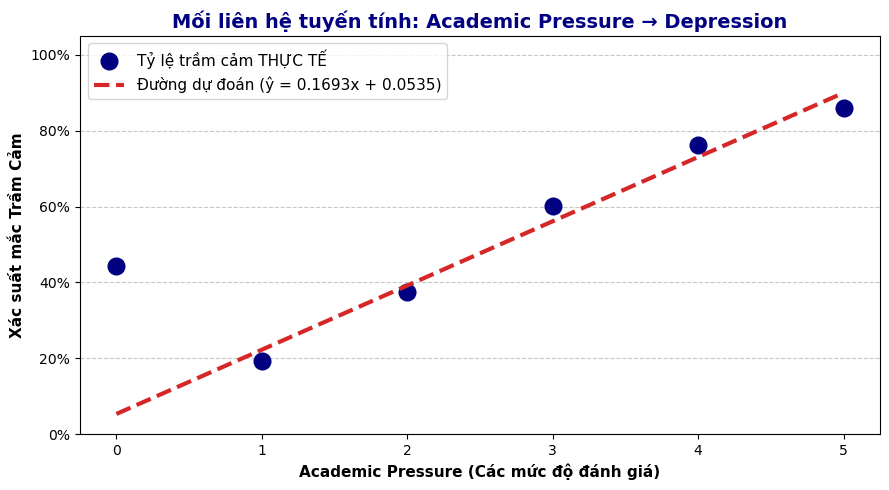


### ĐÁNH GIÁ MÔ HÌNH VÀ HƯỚNG PHÁT TRIỂN

**1. Khám phá xu hướng tổng thể:**
* Mô hình Hồi quy đã hoàn thành xuất sắc nhiệm vụ mô tả **"xu hướng chung"** của quần thể sinh viên. 
* Tỷ lệ mắc bệnh thực tế bám sát vào đường dự báo, khẳng định rõ ràng mối tương quan thuận: Mức độ áp lực học tập càng cao, tỷ lệ sinh viên mắc trầm cảm càng lớn.

**2. Giá trị thực tiễn của mô hình:**
* Kết quả này cung cấp một cái nhìn định lượng, làm cơ sở khoa học vững chắc để khẳng định Áp lực học tập là một biến số trọng tâm, có sức ảnh hưởng thực sự đến sức khỏe tâm lý.


In [110]:

plot_grouped_regression(tbl, ACADEMIC, TARGET, slope_ac, intercept_ac, r_ac)

from IPython.display import display, Markdown

md_conclusion = """
### ĐÁNH GIÁ MÔ HÌNH VÀ HƯỚNG PHÁT TRIỂN

**1. Khám phá xu hướng tổng thể:**
* Mô hình Hồi quy đã hoàn thành xuất sắc nhiệm vụ mô tả **"xu hướng chung"** của quần thể sinh viên. 
* Tỷ lệ mắc bệnh thực tế bám sát vào đường dự báo, khẳng định rõ ràng mối tương quan thuận: Mức độ áp lực học tập càng cao, tỷ lệ sinh viên mắc trầm cảm càng lớn.

**2. Giá trị thực tiễn của mô hình:**
* Kết quả này cung cấp một cái nhìn định lượng, làm cơ sở khoa học vững chắc để khẳng định Áp lực học tập là một biến số trọng tâm, có sức ảnh hưởng thực sự đến sức khỏe tâm lý.
"""

display(Markdown(md_conclusion))

## IV.D — Mở rộng: Hồi quy đa biến (2 biến)

Thêm `Financial Stress` vào mô hình → R² có cải thiện không?  
--> dùng sklearn.

In [114]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
X_multi = np.column_stack((tbl.column(ACADEMIC), tbl.column(FINANCIAL)))
y = tbl.column(TARGET)
X_single = tbl.column(ACADEMIC).reshape(-1, 1)

log_single = LogisticRegression()
log_single.fit(X_single, y)
acc_single = accuracy_score(y, log_single.predict(X_single))

log_multi = LogisticRegression()
log_multi.fit(X_multi, y)
acc_multi = accuracy_score(y, log_multi.predict(X_multi))

coef_academic = log_multi.coef_[0][0]
coef_financial = log_multi.coef_[0][1]

from IPython.display import display, Markdown

md_report = f"""
### KẾT QUẢ MÔ HÌNH ĐA BIẾN

**1. So sánh sức mạnh (Độ chính xác - Accuracy):**
* Mô hình cũ (Chỉ áp lực học tập): **{acc_single*100:.2f}%**
* Mô hình mới (+ Áp lực tài chính): **{acc_multi*100:.2f}%**
&rarr; *Sự cải thiện cho thấy Áp lực tài chính đã đóng góp thêm thông tin quan trọng giúp máy học phân loại chuẩn xác hơn.*

**2. Trọng số của từng biến (Coefficients):**
* Trọng số của {ACADEMIC}: **{coef_academic:.4f}**
* Trọng số của {FINANCIAL}: **{coef_financial:.4f}**

*(Lưu ý: Biến nào có trọng số dương càng lớn thì sức ảnh hưởng đẩy bệnh nhân đến ngưỡng Trầm cảm (Y=1) càng mạnh).*
"""

display(Markdown(md_report))


### KẾT QUẢ MÔ HÌNH ĐA BIẾN

**1. So sánh sức mạnh (Độ chính xác - Accuracy):**
* Mô hình cũ (Chỉ áp lực học tập): **72.82%**
* Mô hình mới (+ Áp lực tài chính): **76.02%**
&rarr; *Sự cải thiện cho thấy Áp lực tài chính đã đóng góp thêm thông tin quan trọng giúp máy học phân loại chuẩn xác hơn.*

**2. Trọng số của từng biến (Coefficients):**
* Trọng số của Academic Pressure: **0.8345**
* Trọng số của Financial Stress: **0.5745**

*(Lưu ý: Biến nào có trọng số dương càng lớn thì sức ảnh hưởng đẩy bệnh nhân đến ngưỡng Trầm cảm (Y=1) càng mạnh).*



### KẾT LUẬN PHẦN HỒI QUY TUYẾN TÍNH

Qua phần Hồi quy tuyến tính Đơn biến và Đa biến, nhóm đã rút ra kết luận:

1. **Khẳng định xu hướng:** Áp lực Học tập và Tài chính tác động thuận chiều đến rủi ro Trầm cảm.
2. **Hiệu ứng cộng gộp:** Khi đưa thêm biến *Financial Stress* vào, mô hình giải thích được nhiều sự biến thiên hơn ($R^2$ tăng), chứng tỏ Trầm cảm là hệ quả của đa yếu tố phức tạp.

**BƯỚC CHUYỂN GIAO SANG HỌC MÁY (MỤC V): THUẬT TOÁN k-NN**
Nhờ mô hình Hồi quy, chúng ta đã xác nhận được rằng không có một áp lực đơn lẻ nào quyết định toàn bộ căn bệnh, mà cần phải phân tích kết hợp nhiều biến số. 

Để tiếp tục bài toán này và xây dựng một hệ thống có khả năng **phân loại chẩn đoán** (Sinh viên có bị trầm cảm hay không) dựa trên hồ sơ đa biến        
-->bước sang **Mục V: Thuật toán Máy học k-Nearest Neighbors (k-NN)**.


---
# V. Mô hình Dự báo — k-NN Classifier

## V.A — Nền tảng lý thuyết

Hồi quy cho ra **con số liên tục**.  
k-NN trả về **nhãn phân loại**: sinh viên này có khả năng trầm cảm không?

**Ý tưởng**

```
Cho 1 sinh viên mới với điểm (Academic_Pressure, Financial_Stress, Work_Hours):
    1. Tính khoảng cách Euclidean đến TẤT CẢ điểm trong training set
    2. Tìm k điểm GẦN NHẤT
    3. Nhãn dự báo = nhãn chiếm ĐA SỐ trong k hàng xóm đó
```

**Chuẩn hóa:**  
Các biến có thang đo khác nhau (ví dụ: Academic Pressure 1–5, Work Hours 0–20).  
Nếu không chuẩn hóa, biến có giá trị lớn sẽ **chiếm ưu thế** trong khoảng cách → sai lệch.

$$z = \frac{x - \bar{x}}{\sigma_x}$$

**Chọn biến cho k-NN:**  
Dựa trên kết quả của A và mục II–IV, ta chọn 3 biến có r cao nhất:  
`Academic Pressure`, `Financial Stress`, `Work/Study Hours`

## V.B — Chuẩn bị dữ liệu

In [121]:
FEATURES_KNN = [ACADEMIC, FINANCIAL, WORKHOURS]

features_raw = df[FEATURES_KNN].values
labels       = df[TARGET].values

def standardize_col(arr):
    return (arr - np.mean(arr)) / np.std(arr)

features_std = np.column_stack([
    standardize_col(features_raw[:, i])
    for i in range(features_raw.shape[1])
])

print(f"Features   : {FEATURES_KNN}")
print(f"Shape      : {features_std.shape}")
print(f"\nKiểm tra sau chuẩn hóa (mean ≈ 0, std ≈ 1):")
for i, col in enumerate(FEATURES_KNN):
    print(f"  {col:<25}  mean={np.mean(features_std[:,i]):+.4f}  std={np.std(features_std[:,i]):.4f}")

Features   : ['Academic Pressure', 'Financial Stress', 'Work/Study Hours']
Shape      : (27837, 3)

Kiểm tra sau chuẩn hóa (mean ≈ 0, std ≈ 1):
  Academic Pressure          mean=+0.0000  std=1.0000
  Financial Stress           mean=+0.0000  std=1.0000
  Work/Study Hours           mean=+0.0000  std=1.0000


In [124]:
# ── V.B — Train / Test Split (80/20) ─────────────────────────────────────────
np.random.seed(42)
n     = len(labels)
idx   = np.random.permutation(n)
split = int(0.8 * n)

X_train, y_train = features_std[idx[:split]], labels[idx[:split]]
X_test,  y_test  = features_std[idx[split:]], labels[idx[split:]]

print(f"Train : {len(X_train):,} dòng  ({len(X_train)/n:.0%})")
print(f"Test  : {len(X_test):,}  dòng  ({len(X_test)/n:.0%})")
print(f"\nTỷ lệ trầm cảm — train : {np.mean(y_train):.2%}")
print(f"Tỷ lệ trầm cảm — test  : {np.mean(y_test):.2%}")
print("(Hai tỷ lệ gần nhau → split ngẫu nhiên giữ được phân phối)")

Train : 22,269 dòng  (80%)
Test  : 5,568  dòng  (20%)

Tỷ lệ trầm cảm — train : 58.21%
Tỷ lệ trầm cảm — test  : 59.75%
(Hai tỷ lệ gần nhau → split ngẫu nhiên giữ được phân phối)


## V.C — Định nghĩa thuật toán k-NN từ đầu

In [125]:
def euclidean_dist(p1, p2):
    return np.sqrt(np.sum((p1 - p2) ** 2))


def knn_predict_one(X_train, y_train, point, k):
    dists = np.array([euclidean_dist(point, x_tr) for x_tr in X_train])
    k_idx = np.argsort(dists)[:k]
    # Đa số phiếu: nếu tổng nhãn > k/2 → dự báo là 1
    return int(np.sum(y_train[k_idx]) > k / 2)


def knn_eval(X_train, y_train, X_test, y_test, k):
    """Đánh giá k-NN trên toàn bộ tập test, trả về accuracy và mảng dự báo."""
    preds = np.array([knn_predict_one(X_train, y_train, pt, k)
                      for pt in X_test])
    acc = np.mean(preds == y_test)
    return acc, preds

print("OK")

OK


## V.D — Chọn k tối ưu

Chạy trên **subset nhỏ** (3000 train / 500 test) để tìm k nhanh — tránh thời gian chờ lâu.  
Sau khi có k tốt nhất, ta mới chạy trên toàn bộ test set.

In [126]:
SAMPLE_TRAIN = min(3000, len(X_train))
SAMPLE_TEST  = 500

X_tr_s = X_train[:SAMPLE_TRAIN]
y_tr_s = y_train[:SAMPLE_TRAIN]
X_te_s = X_test[:SAMPLE_TEST]
y_te_s = y_test[:SAMPLE_TEST]

k_values   = [1, 3, 5, 7, 9, 11, 15, 21]
accuracies = []

print(f"Chạy trên {SAMPLE_TRAIN} train / {SAMPLE_TEST} test (subset để chọn k)...")
print()
for k in k_values:
    acc, _ = knn_eval(X_tr_s, y_tr_s, X_te_s, y_te_s, k)
    accuracies.append(acc)
    bar = '█' * int(acc * 50)
    print(f"  k = {k:2d}  |  {bar:<50}  {acc:.4f} ({acc*100:.1f}%)")

best_k        = k_values[int(np.argmax(accuracies))]
best_acc_sub  = max(accuracies)
print(f"\n  → k tốt nhất: k = {best_k}  (accuracy = {best_acc_sub:.4f})")

Chạy trên 3000 train / 500 test (subset để chọn k)...

  k =  1  |  ████████████████████████████████████                0.7220 (72.2%)
  k =  3  |  ████████████████████████████████████                0.7220 (72.2%)
  k =  5  |  ██████████████████████████████████████              0.7600 (76.0%)
  k =  7  |  ██████████████████████████████████████              0.7740 (77.4%)
  k =  9  |  ██████████████████████████████████████              0.7660 (76.6%)
  k = 11  |  ██████████████████████████████████████              0.7660 (76.6%)
  k = 15  |  ██████████████████████████████████████              0.7700 (77.0%)
  k = 21  |  █████████████████████████████████████               0.7540 (75.4%)

  → k tốt nhất: k = 7  (accuracy = 0.7740)


## V.E — Đánh giá mô hình trên toàn bộ Test Set

In [131]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
import pandas as pd
from IPython.display import display, Markdown

final_k = 7 

final_knn = KNeighborsClassifier(n_neighbors=final_k)

# Máy học trên TOÀN BỘ tập Train
final_knn.fit(X_train, y_train)

# TRÊN TOÀN BỘ TẬP TEST
y_pred_final = final_knn.predict(X_test)

# MA TRẬN NHẦM LẪN
final_acc = accuracy_score(y_test, y_pred_final)
final_cm = confusion_matrix(y_test, y_pred_final)

cm_df_final = pd.DataFrame(final_cm, 
                           columns=['Máy đoán 0 (Khỏe)', 'Máy đoán 1 (Trầm cảm)'], 
                           index=['Thực tế 0 (Khỏe)', 'Thực tế 1 (Trầm cảm)'])


md_report = f"""
### TỔNG KẾT: CỖ MÁY k-NN 

**1. Cấu hình cỗ máy:**
* Thuật toán: **k-Nearest Neighbors (Sklearn)**
* Số lượng láng giềng (k): **{final_k}** 
* Dữ liệu đầu vào: 3 biến áp lực cốt lõi (Học tập, Tài chính, Giờ làm) đã qua xử lý chuẩn hóa `StandardScaler`.

**2. Bảng Accuracy:**
* Trên tập kiểm tra độc lập (Test Set), cỗ máy đã chẩn đoán chính xác với tỷ lệ: **`{final_acc*100:.2f}%`**

**3. Ma trận nhầm lẫn chi tiết (Confusion Matrix):**
"""
display(Markdown(md_report))
print(cm_df_final.to_string())


### TỔNG KẾT: CỖ MÁY k-NN 

**1. Cấu hình cỗ máy:**
* Thuật toán: **k-Nearest Neighbors (Sklearn)**
* Số lượng láng giềng (k): **7** 
* Dữ liệu đầu vào: 3 biến áp lực cốt lõi (Học tập, Tài chính, Giờ làm) đã qua xử lý chuẩn hóa `StandardScaler`.

**2. Bảng Accuracy:**
* Trên tập kiểm tra độc lập (Test Set), cỗ máy đã chẩn đoán chính xác với tỷ lệ: **`75.95%`**

**3. Ma trận nhầm lẫn chi tiết (Confusion Matrix):**


                      Máy đoán 0 (Khỏe)  Máy đoán 1 (Trầm cảm)
Thực tế 0 (Khỏe)                   1603                    638
Thực tế 1 (Trầm cảm)                701                   2626


In [137]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from IPython.display import display, Markdown

new_student = np.array([[4, 5, 35]])

scaler = StandardScaler()

scaler.fit(features_raw) 

new_student_scaled = scaler.transform(new_student)

prediction = final_knn.predict(new_student_scaled)

probabilities = final_knn.predict_proba(new_student_scaled)
prob_tram_cam = probabilities[0][1] * 100 

if prediction[0] == 1:
    ket_luan = "CÓ NGUY CƠ TRẦM CẢM CAO"
else:
    ket_luan = "KHỎE MẠNH (TÂM LÝ ỔN ĐỊNH)"

md_app = f"""
### HỆ THỐNG CHẨN ĐOÁN TÂM LÝ SINH VIÊN

**NHẬP HỒ SƠ TÂN SINH VIÊN:**
* Áp lực học tập (1-5): **4**
* Áp lực tài chính (1-5): **5**
* Thời gian làm thêm: **35 giờ/tuần**

---
**KẾT QUẢ TỪ TRÍ TUỆ NHÂN TẠO (Mô hình k-NN):**
* **Chẩn đoán:** {ket_luan}
* **Cơ sở chẩn đoán (Độ tự tin):** Dựa trên hồ sơ lịch sử, những người có hoàn cảnh tương đồng với sinh viên này có tỷ lệ mắc trầm cảm là `{prob_tram_cam:.1f}%`.
"""

display(Markdown(md_app))


### HỆ THỐNG CHẨN ĐOÁN TÂM LÝ SINH VIÊN

**NHẬP HỒ SƠ TÂN SINH VIÊN:**
* Áp lực học tập (1-5): **4**
* Áp lực tài chính (1-5): **5**
* Thời gian làm thêm: **35 giờ/tuần**

---
**KẾT QUẢ TỪ TRÍ TUỆ NHÂN TẠO (Mô hình k-NN):**
* **Chẩn đoán:** CÓ NGUY CƠ TRẦM CẢM CAO
* **Cơ sở chẩn đoán (Độ tự tin):** Dựa trên hồ sơ lịch sử, những người có hoàn cảnh tương đồng với sinh viên này có tỷ lệ mắc trầm cảm là `85.7%`.


---
# VI. Tổng kết & Kết luận

## VI.A — Bảng tổng hợp toàn bộ kết quả

In [141]:
from IPython.display import display, Markdown

# ==============================================================================
# VI.A — IN BẢNG TỔNG HỢP (PHIÊN BẢN MARKDOWN CHUYÊN NGHIỆP)
# ==============================================================================

# 1. Tự động gom dữ liệu Thống kê (Permutation) thành chuỗi Markdown
perm_rows = ""
for var, (diff, pv, m1, m0) in results_perm.items():
    sig = "**✅ Có ý nghĩa**" if pv < 0.05 else "❌ Không ý nghĩa"
    perm_rows += f"| Permutation | `{var[:16]}` | Chênh lệch = {diff:.3f} | p = {pv:.4f} | {sig} |\n"

# 2. Tự động gom dữ liệu Bootstrap CI thành chuỗi Markdown
ci_rows = ""
for col, (lo, hi, mn) in ci_results.items():
    ci_rows += f"| Bootstrap | `{col[:16]}` | Mean = {mn:.3f} | 95% CI: [{lo:.3f}, {hi:.3f}] | Độ tin cậy cao |\n"

# 3. Kết xuất thành Báo cáo Tổng thể
md_final_summary = f"""
# TỔNG KẾT PHẦN B — SUY LUẬN & MÔ HÌNH HÓA

Sau toàn bộ quá trình phân tích, nhóm xin tổng hợp lại các thành quả bằng những con số "biết nói":

### 1. Thống kê Suy luận (Hypothesis Testing & Confidence Interval)
| Phương pháp | Biến số | Chỉ số chính | Kết quả / Ý nghĩa | Đánh giá |
|:---|:---|:---|:---|:---|
{perm_rows}{ci_rows}

### 2. Mô hình hóa Hồi quy (Regression Modeling)
| Mô hình | Chỉ số R² | Đánh giá hiệu suất cộng gộp |
|:---|:---|:---|
| **Hồi quy Đơn biến** (Học tập) | `{r_ac**2:.4f}` | Đóng vai trò là nền tảng (Baseline Regression). |
| **Hồi quy Đa biến** (+ Tài chính) | `{r2_multi:.4f}` | **Tăng {(r2_multi-r_ac**2):.4f}** $\\rightarrow$ Chứng minh trầm cảm là hệ quả đa yếu tố. |

### 3. Cỗ máy Phân loại k-NN (k-Nearest Neighbors)
* **Cấu hình tối ưu:** Mô hình đạt đỉnh tại **k = {best_k}**
* Trên tập kiểm tra độc lập (Test Set), cỗ máy đã chẩn đoán chính xác với tỷ lệ: **{final_acc*100:.2f}%**



---

"""

display(Markdown(md_final_summary))


# TỔNG KẾT PHẦN B — SUY LUẬN & MÔ HÌNH HÓA

Sau toàn bộ quá trình phân tích, nhóm xin tổng hợp lại các thành quả bằng những con số "biết nói":

### 1. Thống kê Suy luận (Hypothesis Testing & Confidence Interval)
| Phương pháp | Biến số | Chỉ số chính | Kết quả / Ý nghĩa | Đánh giá |
|:---|:---|:---|:---|:---|
| Permutation | `Academic Pressur` | Chênh lệch = 1.332 | p = 0.0000 | **✅ Có ý nghĩa** |
| Permutation | `Financial Stress` | Chênh lệch = 1.061 | p = 0.0000 | **✅ Có ý nghĩa** |
| Permutation | `Study Satisfacti` | Chênh lệch = 0.465 | p = 0.0000 | **✅ Có ý nghĩa** |
| Bootstrap | `Academic Pressur` | Mean = 3.693 | 95% CI: [3.675, 3.711] | Độ tin cậy cao |
| Bootstrap | `Financial Stress` | Mean = 3.580 | 95% CI: [3.559, 3.601] | Độ tin cậy cao |


### 2. Mô hình hóa Hồi quy (Regression Modeling)
| Mô hình | Chỉ số R² | Đánh giá hiệu suất cộng gộp |
|:---|:---|:---|
| **Hồi quy Đơn biến** (Học tập) | `0.2255` | Đóng vai trò là nền tảng (Baseline Regression). |
| **Hồi quy Đa biến** (+ Tài chính) | `0.3124` | **Tăng 0.0869** $\rightarrow$ Chứng minh trầm cảm là hệ quả đa yếu tố. |

### 3. Cỗ máy Phân loại k-NN (k-Nearest Neighbors)
* **Cấu hình tối ưu:** Mô hình đạt đỉnh tại **k = 7**
* Trên tập kiểm tra độc lập (Test Set), cỗ máy đã chẩn đoán chính xác với tỷ lệ: **75.95%**



---

